# 🗺️ Algiers in 24 Hours — Complete Tour Optimizer

**Project 6 | AI Course | ENSIA | May 2026**

---

## Project Overview

This notebook implements a **complete Tour Planning Optimization System** for tourists  
visiting Algiers with a limited time budget.  
The goal is to select and order the optimal subset of city landmarks to  
**maximise total Interest Score** within a strict time budget — the **Orienteering Problem**.

### Algorithms Implemented

| # | Algorithm | Family |
|---|---|---|
| 1 | **Greedy (Nearest-Neighbour)** | Constructive baseline |
| 2 | **Simulated Annealing (SA)** | Local Search |
| 3 | **GA — Score-based fitness** | Evolutionary |
| 4 | **GA — Tailored fitness** | Evolutionary |
| 5 | **GRASP** | Metaheuristic |
| 6 | **Tabu Search** | Local Search |
| 7 | **ILP (CPLEX-style via PuLP)** | Exact / MIP |

### Problem Formulation
- **Start & End**: Tourist's Hotel  
- **Hard constraint**: Total Time (Travel + Visit) ≤ T_max  
- **Objective**: Maximise Σ Interest_Score_i for all visited landmarks i

### Dataset
59 real Algiers landmarks with GPS coordinates, opening hours, visit durations  
and interest scores. Data lives in `data/data.csv` and `data/hotel.csv`.

> ⚠️ **Note on non-determinism**: SA, all GA variants, GRASP, and Tabu Search use  
> random operations. Scores and rankings **can differ between runs**.  
> Only the ILP solver is fully deterministic and always returns the exact optimum.  
> Greedy is also deterministic (no randomness). Set `SEED` below to reproduce results.


## 1 · Setup & Imports

In [2]:
import math, random, time, copy, warnings, itertools
from dataclasses import dataclass, field
from enum import IntEnum
from typing import Optional, List, Dict, Tuple

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines

try:
    import pulp
    PULP_OK = True
except ImportError:
    PULP_OK = False
    print("⚠  PuLP not installed – ILP solver will be skipped.")

warnings.filterwarnings('ignore')

# Set this seed to reproduce a specific run; change it to explore variability
SEED = 42
random.seed(SEED); np.random.seed(SEED)

print("✓  All imports successful.")
if PULP_OK:
    print(f"   PuLP {pulp.__version__} — ILP solver enabled.")


⚠  PuLP not installed – ILP solver will be skipped.
✓  All imports successful.


## 2 · Data Models

Core structures matching `algiers-lib/models/`:

- **`Day`** – day-of-week enum (Sunday = 0 … Saturday = 6)
- **`TimeSlot`** – (open_time, close_time) in minutes since midnight
- **`WeeklySchedule`** – maps days → list of TimeSlots; finds earliest valid visit start
- **`Landmark`** – immutable record for each visitable location


In [27]:
class Day(IntEnum):
    SUNDAY=0; MONDAY=1; TUESDAY=2; WEDNESDAY=3; THURSDAY=4; FRIDAY=5; SATURDAY=6

    @classmethod
    def from_string(cls, s: str) -> "Day":
        try:    return cls[s.strip().upper()]
        except KeyError: raise ValueError(f"Bad day string: '{s}'")


@dataclass(frozen=True)
class TimeSlot:
    open_time:  int
    close_time: int

    def __post_init__(self):
        if self.open_time >= self.close_time:
            raise ValueError(f"open_time {self.open_time} >= close_time {self.close_time}")

    def contains(self, arrival: float, duration: float) -> bool:
        return self.open_time <= arrival and (arrival + duration) <= self.close_time


@dataclass
class WeeklySchedule:
    schedule: Dict[Day, List[TimeSlot]] = field(default_factory=dict)

    def is_open_on(self, day: Day) -> bool:
        return bool(self.schedule.get(day))

    def get_slots(self, day: Day) -> List[TimeSlot]:
        return self.schedule.get(day, [])

    def earliest_valid_start(self, day: Day, arrival: float, duration: float) -> Optional[float]:
        for slot in self.get_slots(day):
            start = max(arrival, float(slot.open_time))
            if slot.contains(start, duration):
                return start
        return None


@dataclass(frozen=True)
class Landmark:
    id:             str
    name:           str
    latitude:       float
    longitude:      float
    interest_score: float
    visit_duration: int       # minutes
    schedule:       WeeklySchedule
    category:       str

    @property
    def coordinates(self) -> Tuple[float, float]:
        return (self.latitude, self.longitude)

    def __hash__(self):  return hash(self.id)
    def __eq__(self, o): return isinstance(o, Landmark) and self.id == o.id
    def __str__(self):
        return f"{self.name} [{self.category}] score={self.interest_score} dur={self.visit_duration}min"

print("✓  Data models ready.")


✓  Data models ready.


## 3 · Data Loading

`data/data.csv` has one row per (landmark, day, time-slot) — the same schema as  
`algiers-lib/data/data.csv`. We group by landmark ID and build a `WeeklySchedule`.


In [28]:
def time_in_minutes(s: str) -> int:
    h, m = map(int, str(s).split(':'))
    return h * 60 + m

def minutes_to_str(mins: float) -> str:
    mins = int(mins)
    return f"{mins//60:02d}:{mins%60:02d}"

def load_landmarks(path: str = "data/data.csv") -> List[Landmark]:
    df = pd.read_csv(path)
    out = []
    for lm_id, grp in df.groupby("id"):
        slots: Dict[Day, List[TimeSlot]] = {}
        for _, row in grp.iterrows():
            day  = Day.from_string(str(row["day"]))
            slot = TimeSlot(time_in_minutes(row["open_time"]),
                            time_in_minutes(row["close_time"]))
            slots.setdefault(day, []).append(slot)
        r = grp.iloc[0]
        out.append(Landmark(
            id=str(r["id"]), name=str(r["name"]),
            latitude=float(r["latitude"]), longitude=float(r["longitude"]),
            interest_score=float(r["interest_score"]),
            visit_duration=int(r["visit_duration_minutes"]),
            schedule=WeeklySchedule(schedule=slots),
            category=str(r["category"])
        ))
    return out

def load_hotel(path: str = "data/hotel.csv") -> Landmark:
    r = pd.read_csv(path).iloc[0]
    sched = WeeklySchedule()
    for day in Day:
        sched.schedule[day] = [TimeSlot(0, 1439)]
    return Landmark(id=str(r["id"]), name=str(r["name"]),
                    latitude=float(r["latitude"]), longitude=float(r["longitude"]),
                    interest_score=0.0, visit_duration=0,
                    schedule=sched, category="Hotel")

LANDMARKS = load_landmarks("data/data.csv")
HOTEL     = load_hotel("data/hotel.csv")

print(f"✓  Loaded {len(LANDMARKS)} landmarks + hotel '{HOTEL.name}'")
df_display = pd.DataFrame([{
    "Name": lm.name, "Category": lm.category,
    "Score": lm.interest_score, "Duration (min)": lm.visit_duration,
} for lm in LANDMARKS])
print(df_display.to_string(index=False))


✓  Loaded 56 landmarks + hotel 'Hotel El-Aurassi'
                                            Name      Category  Score  Duration (min)
                                 Algerian Cinema    attraction    7.6             180
                             Algiers Opera House tradition_art    9.0             120
                              Ali Bitchin Mosque    historical    9.2              30
                                    Audin Square    attraction    8.8              30
                                Bab Ezzouar Mall      shopping    7.7             120
Bardo National Museum (Prehistory & Ethnography)    historical    8.9              90
                           Ben Aknoun Park & Zoo    attraction    5.6             120
                    Casbah of Algiers (Old City)    historical    8.9             120
                                 Cinéma El Sahel    attraction    7.4             180
                            Cosmos Movie Theater    attraction    7.7             180
    

## 4 · Dataset Exploration

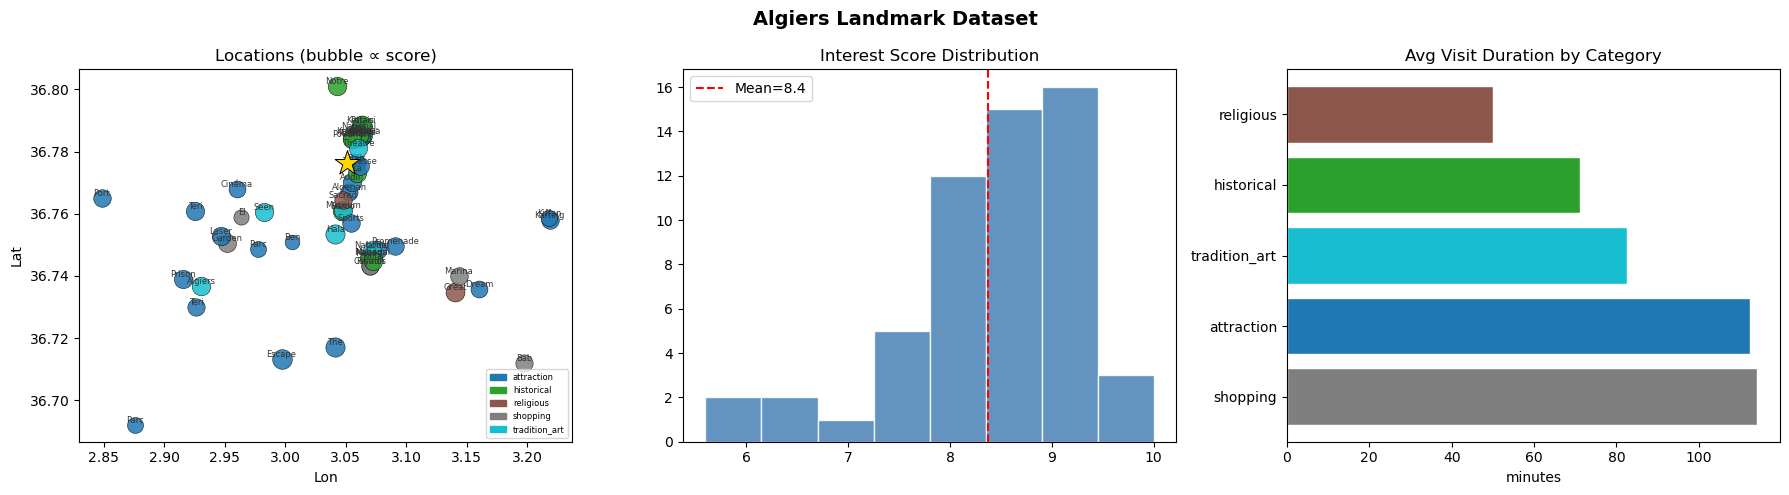

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Algiers Landmark Dataset", fontsize=14, fontweight='bold')

cats      = sorted({lm.category for lm in LANDMARKS})
cmap      = plt.cm.get_cmap('tab10', len(cats))
cat_color = {c: cmap(i) for i, c in enumerate(cats)}

ax = axes[0]
for lm in LANDMARKS:
    ax.scatter(lm.longitude, lm.latitude, color=cat_color[lm.category],
               s=lm.interest_score*20, alpha=0.85, edgecolors='k', linewidths=0.4)
    ax.annotate(lm.name.split()[0], (lm.longitude, lm.latitude),
                fontsize=6, ha='center', va='bottom', color='#333')
ax.scatter(HOTEL.longitude, HOTEL.latitude, marker='*', s=350,
           c='gold', edgecolors='k', linewidths=0.7, zorder=5)
ax.set_title("Locations (bubble ∝ score)"); ax.set_xlabel("Lon"); ax.set_ylabel("Lat")
patches = [mpatches.Patch(color=cat_color[c], label=c) for c in cats]
ax.legend(handles=patches, fontsize=6, loc='lower right')

ax = axes[1]
sc = [lm.interest_score for lm in LANDMARKS]
ax.hist(sc, bins=8, color='steelblue', edgecolor='white', alpha=0.85)
ax.axvline(np.mean(sc), color='red', ls='--', label=f'Mean={np.mean(sc):.1f}')
ax.set_title("Interest Score Distribution"); ax.legend()

ax = axes[2]
cat_dur = {}
for lm in LANDMARKS:
    cat_dur.setdefault(lm.category, []).append(lm.visit_duration)
sorted_cats = sorted(cat_dur, key=lambda c: np.mean(cat_dur[c]), reverse=True)
ax.barh(sorted_cats, [np.mean(cat_dur[c]) for c in sorted_cats],
        color=[cat_color[c] for c in sorted_cats], edgecolor='white')
ax.set_title("Avg Visit Duration by Category"); ax.set_xlabel("minutes")

plt.tight_layout(); plt.show()


## 5 · Distance Model & Problem Class

Matches `algiers-lib/utils/distance.py` (Haversine) and `algiers-lib/models/problem.py`.  
Travel speed = **25 km/h** (urban Algiers). Travel-time matrix pre-computed O(n²).


In [30]:
AVG_SPEED_KMH = 25.0

def haversine_km(p1, p2) -> float:
    R = 6371.0
    lat1, lon1 = math.radians(p1[0]), math.radians(p1[1])
    lat2, lon2 = math.radians(p2[0]), math.radians(p2[1])
    dlat, dlon = lat2-lat1, lon2-lon1
    a = math.sin(dlat/2)**2 + math.cos(lat1)*math.cos(lat2)*math.sin(dlon/2)**2
    return R * 2 * math.asin(math.sqrt(a))

def travel_time_min(p1, p2) -> float:
    return (haversine_km(p1, p2) / AVG_SPEED_KMH) * 60.0


class Problem:
    def __init__(self, hotel: Landmark, landmarks: List[Landmark],
                 time_budget: int, tour_day: Day, start_time: int = 540):
        self.hotel       = hotel
        self.landmarks   = landmarks
        self.time_budget = time_budget
        self.tour_day    = tour_day
        self.start_time  = start_time
        self._mat: Dict[Tuple[str, str], float] = {}
        self._build_matrix()

    def _build_matrix(self):
        all_locs = [self.hotel] + self.landmarks
        for a in all_locs:
            for b in all_locs:
                if a.id != b.id:
                    self._mat[(a.id, b.id)] = travel_time_min(a.coordinates, b.coordinates)

    def travel_time(self, a: Landmark, b: Landmark) -> float:
        return 0.0 if a.id == b.id else self._mat[(a.id, b.id)]

    def unvisited(self, tour) -> List[Landmark]:
        ids = {lm.id for lm in tour.stops}
        return [lm for lm in self.landmarks if lm.id not in ids]

    def candidates(self, tour) -> List[Landmark]:
        return [lm for lm in self.unvisited(tour) if lm.schedule.is_open_on(self.tour_day)]

    def random_tour(self) -> "Tour":
        t = Tour(self)
        pool = self.candidates(t)[:]
        random.shuffle(pool)
        for lm in pool:
            t.stops.append(lm); t._cache = None
            if not t.is_valid():
                t.stops.pop(); t._cache = None
        return t

    def __repr__(self):
        return (f"Problem(n={len(self.landmarks)}, budget={self.time_budget}min,"
                f" day={self.tour_day.name})")

print("✓  Problem class ready.")


✓  Problem class ready.


## 6 · Tour Representation & Simulation

Matches `algiers-lib/models/tour.py`.  
`simulate()` enforces time windows and the total budget step by step.  
Results are cached and invalidated on every modification.


In [31]:
@dataclass
class ScheduleEntry:
    landmark:         Landmark
    arrival_time:     float
    visit_start_time: float
    departure_time:   float = field(init=False)

    def __post_init__(self):
        self.departure_time = self.visit_start_time + self.landmark.visit_duration


@dataclass
class SimResult:
    total_duration: float
    is_valid:       bool
    entries:        List[ScheduleEntry] = field(default_factory=list)


class Tour:
    def __init__(self, problem: Problem, stops: Optional[List[Landmark]] = None):
        self.problem = problem
        self.stops: List[Landmark] = stops[:] if stops else []
        self._cache: Optional[SimResult] = None

    def simulate(self) -> SimResult:
        entries = []
        cur_pos  = self.problem.hotel
        cur_time = float(self.problem.start_time)
        for lm in self.stops:
            tt      = self.problem.travel_time(cur_pos, lm)
            arrival = cur_time + tt
            vs      = lm.schedule.earliest_valid_start(
                          self.problem.tour_day, arrival, lm.visit_duration)
            if vs is None:
                return SimResult(arrival + self.problem.travel_time(lm, self.problem.hotel)
                                 - self.problem.start_time, False, entries)
            entries.append(ScheduleEntry(lm, arrival, vs))
            cur_time = entries[-1].departure_time
            cur_pos  = lm
        ret_tt = self.problem.travel_time(cur_pos, self.problem.hotel)
        total  = (cur_time + ret_tt) - self.problem.start_time
        return SimResult(total, total <= self.problem.time_budget, entries)

    def _sim(self) -> SimResult:
        if self._cache is None: self._cache = self.simulate()
        return self._cache

    def _inv(self): self._cache = None

    def is_valid(self) -> bool:        return self._sim().is_valid
    def total_score(self) -> float:    return sum(lm.interest_score for lm in self.stops)
    def total_duration(self) -> float: return self._sim().total_duration

    def copy(self) -> "Tour":
        return Tour(self.problem, self.stops[:])

    def add(self, lm: Landmark, pos: int = None):
        if pos is None: self.stops.append(lm)
        else:           self.stops.insert(pos, lm)
        self._inv()

    def remove(self, lm: Landmark):
        self.stops.remove(lm); self._inv()

    def swap(self, i: int, j: int):
        self.stops[i], self.stops[j] = self.stops[j], self.stops[i]; self._inv()

    def itinerary(self) -> str:
        sim = self._sim()
        sep = "-" * 65
        lines = [sep,
                 f"Hotel '{self.problem.hotel.name}'  "
                 f"depart {minutes_to_str(self.problem.start_time)}"]
        for e in sim.entries:
            lines.append(f"  -> {e.landmark.name:<40s}  "
                         f"arrive {minutes_to_str(e.arrival_time)}  "
                         f"visit {minutes_to_str(e.visit_start_time)}"
                         f"-{minutes_to_str(e.departure_time)}")
        end = self.problem.start_time + sim.total_duration
        lines += [f"  <- Hotel  (return {minutes_to_str(end)})", sep,
                  f"Total duration : {sim.total_duration:.0f} / {self.problem.time_budget} min",
                  f"Total score    : {self.total_score():.1f}",
                  f"Valid          : {sim.is_valid}"]
        return "\n".join(lines)

    def __repr__(self):
        return (f"Tour(score={self.total_score():.1f}, valid={self.is_valid()}, "
                f"stops={len(self.stops)})")

print("✓  Tour class ready.")


✓  Tour class ready.


## 7 · Algorithm 1 — Greedy (Nearest-Neighbour)

Matches `algiers-lib/solvers/greedy_solver.py`.

**Strategy**: at each step, rank all unvisited feasible landmarks by  
(interest_score, −travel_time) and pick the best one that keeps the tour valid.  
Repeat until nothing can be added. Time complexity: **O(n²)**.

This is the **deterministic baseline** — it always gives the same result.


In [32]:
class GreedySolver:
    def __init__(self, problem: Problem, use_ratio: bool = False):
        self.problem   = problem
        self.use_ratio = use_ratio   # if True: rank by score/travel_time ratio

    def _priority(self, lm: Landmark, cur: Landmark):
        tt = self.problem.travel_time(cur, lm)
        if self.use_ratio:
            return lm.interest_score / tt if tt > 0 else float('inf')
        return (lm.interest_score, -tt)

    def solve(self) -> Tour:
        tour = Tour(self.problem)
        while True:
            cur   = tour.stops[-1] if tour.stops else self.problem.hotel
            cands = sorted(self.problem.candidates(tour),
                           key=lambda lm: self._priority(lm, cur), reverse=True)
            added = False
            for lm in cands:
                tour.add(lm)
                if tour.is_valid(): added = True; break
                tour.remove(lm)
            if not added: break
        return tour

_p720 = Problem(HOTEL, LANDMARKS, 720, Day.MONDAY)
_g    = GreedySolver(_p720).solve()
print("Greedy (720 min / Monday):")
print(_g.itinerary())


Greedy (720 min / Monday):
-----------------------------------------------------------------
Hotel 'Hotel El-Aurassi'  depart 09:00
  -> Escape Rooms - Break the Code             arrive 09:20  visit 13:00-16:00
  -> The Chill Spot                            arrive 16:09  visit 16:09-18:09
  -> Hala Art Gallery                          arrive 18:19  visit 18:19-19:19
  -> Emir Abdelkader Square                    arrive 19:26  visit 19:26-19:56
  -> Jamaa el-Jdid                             arrive 19:58  visit 19:58-20:28
  <- Hotel  (return 20:32)
-----------------------------------------------------------------
Total duration : 692 / 720 min
Total score    : 47.2
Valid          : True


## 8 · Algorithm 2 — Simulated Annealing

Matches `algiers-lib/solvers/simulated_annealing_solver.py`.

### Neighbourhood operators
| Operator | Effect |
|---|---|
| **Swap** | Exchange two random stops |
| **Remove** | Delete one random stop |
| **Add** | Insert a feasible unvisited landmark at a random position |

### Cooling schedule
Geometric: **T(k) = T₀ · α^k**, with T₀ = 5.0, α = 0.995, T_min = 0.01.  
Acceptance: **P = exp(−ΔE / T)** where ΔE is normalised by the maximum possible score.

**Non-deterministic**: different seeds give different final scores.


In [33]:
class SimulatedAnnealingSolver:
    def __init__(self, problem: Problem, T0=5.0, alpha=0.995,
                 T_min=0.01, max_iter=15_000):
        self.problem  = problem
        self.T0       = T0
        self.alpha    = alpha
        self.T_min    = T_min
        self.max_iter = max_iter

    def _neighbour(self, tour: Tour) -> Tour:
        n   = len(tour.stops)
        ops = ['add'] + (['remove'] if n >= 1 else []) + (['swap'] if n >= 2 else [])
        op  = random.choice(ops)
        new = tour.copy()
        if op == 'swap':
            i, j = random.sample(range(n), 2); new.swap(i, j)
        elif op == 'remove':
            new.remove(new.stops[random.randrange(n)])
        else:
            cands = self.problem.candidates(new)
            if cands:
                lm  = random.choice(cands)
                pos = random.randint(0, len(new.stops))
                new.add(lm, pos)
        return new

    def solve(self, initial: Optional[Tour] = None, track: bool = False):
        current = initial.copy() if initial else GreedySolver(self.problem).solve()
        if not current.is_valid(): current = Tour(self.problem)
        best    = current.copy()
        T       = self.T0
        max_sc  = sum(lm.interest_score for lm in self.problem.landmarks) or 1.0
        history = [best.total_score()] if track else None

        for _ in range(self.max_iter):
            if T < self.T_min: break
            nb    = self._neighbour(current)
            if not nb.is_valid(): T *= self.alpha; continue
            delta = nb.total_score() - current.total_score()
            if delta > 0 or random.random() < math.exp(delta / (T * max_sc + 1e-9)):
                current = nb
                if current.total_score() > best.total_score():
                    best = current.copy()
            T *= self.alpha
            if track: history.append(best.total_score())

        return (best, history) if track else best

_sa = SimulatedAnnealingSolver(_p720).solve()
print("Simulated Annealing (720 min / Monday):")
print(_sa.itinerary())


Simulated Annealing (720 min / Monday):
-----------------------------------------------------------------
Hotel 'Hotel El-Aurassi'  depart 09:00
  -> Kettani Square                            arrive 09:04  visit 09:04-09:34
  -> Palais des Rais (Bastion 23)              arrive 09:34  visit 09:34-11:04
  -> Villa Abd-el-Latif                        arrive 11:16  visit 11:16-12:16
  -> Dar Aziza                                 arrive 12:27  visit 12:27-13:27
  -> Ali Bitchin Mosque                        arrive 13:27  visit 13:27-13:57
  -> National Museum of Fine Arts              arrive 14:08  visit 14:08-16:08
  -> Palais Hassan Bacha                       arrive 16:19  visit 16:19-17:19
  -> Audin Square                              arrive 17:23  visit 17:23-17:53
  -> Garden City Mall                          arrive 18:16  visit 18:16-20:16
  <- Hotel  (return 20:38)
-----------------------------------------------------------------
Total duration : 699 / 720 min
Total score    : 78.

## 9 · Genetic Algorithm — Three Fitness Variants

Matches `algiers-lib/solvers/genetic_fitness.py`, `genetic_crossover.py`,  
`genetic_mutation.py`, `genetic_selection.py`, `genetic_solver.py`.

The GA infrastructure (crossover, mutation, selection) is shared across all three variants.  
What differs is **how fitness is evaluated for each tour chromosome**.

---

### 9a · Shared GA Infrastructure

#### OX1 Order Crossover
Preserves the relative visit order of genes from both parents.  
A random segment is copied from parent 1; remaining genes fill in parent-2 order.

#### Mutation: Insert / Delete
With probability `insert_prob` a new landmark is inserted at a random position;  
otherwise a random landmark is removed.

#### Tournament Selection (k = 3)
Three individuals are drawn at random and the best two become parents.

#### Elitism
The top `elite_frac` of valid individuals are copied unchanged to the next generation.


In [34]:
# ── OX1 Order Crossover ────────────────────────────────────────────────────────
def ox1_crossover(p1: Tour, p2: Tour) -> Tuple[Tour, Tour]:
    prob = p1.problem
    s1, s2 = p1.stops, p2.stops
    if not s1 or not s2: return Tour(prob), Tour(prob)
    src, don = (s1, s2) if len(s1) <= len(s2) else (s2, s1)

    def build(seg_par, fill_par):
        n = len(seg_par)
        if n < 2: return seg_par[:]
        a, b    = sorted(random.sample(range(n), 2))
        seg     = seg_par[a:b+1]
        seg_ids = {lm.id for lm in seg}
        fill    = [lm for lm in fill_par if lm.id not in seg_ids]
        child   = [None]*n; child[a:b+1] = seg
        fi = 0
        for i in range(n):
            if child[i] is None and fi < len(fill):
                child[i] = fill[fi]; fi += 1
        return [x for x in child if x is not None]

    return Tour(prob, build(src, don)), Tour(prob, build(don, src))


# ── Mutation ───────────────────────────────────────────────────────────────────
def mutate_tour(tour: Tour, insert_prob: float = 0.5) -> Tour:
    t = tour.copy()
    if not t.stops or random.random() < insert_prob:
        cands = tour.problem.candidates(t)
        if cands:
            t.add(random.choice(cands), random.randint(0, len(t.stops)))
    else:
        t.remove(t.stops[random.randrange(len(t.stops))])
    return t


# ── Tournament selection ───────────────────────────────────────────────────────
def tournament_select(pop: List[Tour], fitness_fn, k: int = 3) -> Tuple[Tour, Tour]:
    grp = sorted(random.sample(pop, min(k, len(pop))),
                 key=fitness_fn, reverse=True)
    return grp[0], grp[1]


print("✓  Shared GA infrastructure defined (OX1 crossover, mutation, tournament selection).")


✓  Shared GA infrastructure defined (OX1 crossover, mutation, tournament selection).


### 9b · GA with Penalty-Based Fitness

Matches `genetic_fitness.py → PenaltyFitnessFunction`.

**Fitness = score − overtime_penalty × overtime − window_penalty × violations**

Infeasible tours receive a continuous penalty proportional to how badly they  
violate constraints. This allows infeasible individuals to survive and be  
improved by crossover — a soft-constraint approach.

**Advantage**: larger effective search space; good average performance.  
**Disadvantage**: may converge on solutions that are still slightly infeasible.


In [51]:
def fitness_penalty(tour: Tour, overtime_pen: float = 1.0,
                    window_pen: float = 10.0) -> float:
    """Penalty-based fitness (PenaltyFitnessFunction in genetic_fitness.py)."""
    sim      = tour.simulate()
    overtime = max(0.0, sim.total_duration - tour.problem.time_budget)
    n_violations = 0 if sim.is_valid else 1   # simplified: infeasible = 1 violation
    return tour.total_score() - overtime_pen * overtime - window_pen * n_violations


class GAPenaltySolver:
    """GA with penalty-based fitness (soft constraints)."""
    def __init__(self, problem: Problem, pop_size=60, generations=500,
                 mutation_rate=0.8, insert_prob=0.35,
                 elite_frac=0.10, patience=80):
        self.problem       = problem
        self.pop_size      = pop_size
        self.generations   = generations
        self.mutation_rate = mutation_rate
        self.insert_prob   = insert_prob
        self.elite_n       = max(1, int(pop_size * elite_frac))
        self.patience      = patience
        self.fitness_fn    = fitness_penalty

    def solve(self, track: bool = False):
        pop  = [self.problem.random_tour() for _ in range(self.pop_size)]
        seed = GreedySolver(self.problem).solve()
        if seed.is_valid(): pop[0] = seed
        best       = max((t for t in pop if t.is_valid()),
                         key=lambda t: t.total_score(), default=pop[0])
        history    = [best.total_score()] if track else None
        no_improve = 0

        for _ in range(self.generations):
            elites   = sorted([t for t in pop if t.is_valid()],
                              key=self.fitness_fn, reverse=True)[:self.elite_n]
            next_pop = [e.copy() for e in elites]
            while len(next_pop) < self.pop_size:
                p1, p2 = tournament_select(pop, self.fitness_fn)
                c1, c2 = ox1_crossover(p1, p2)
                if random.random() < self.mutation_rate:
                    c1 = mutate_tour(c1, self.insert_prob)
                if random.random() < self.mutation_rate:
                    c2 = mutate_tour(c2, self.insert_prob)
                next_pop.extend([c1, c2])
            pop = next_pop[:self.pop_size]
            gen_best = max((t for t in pop if t.is_valid()),
                           key=lambda t: t.total_score(), default=best)
            if gen_best.total_score() > best.total_score():
                best = gen_best.copy(); no_improve = 0
            else:
                no_improve += 1
            if track: history.append(best.total_score())
            if no_improve >= self.patience: break

        return (best, history) if track else best

_ga_pen = GAPenaltySolver(_p720, pop_size=50, generations=300).solve()
print("GA Penalty (720 min / Monday):")
print(_ga_pen.itinerary())


GA Penalty (720 min / Monday):
-----------------------------------------------------------------
Hotel 'Hotel El-Aurassi'  depart 09:00
  -> Dar Aziza                                 arrive 09:03  visit 09:03-10:03
  -> La Grande Poste d'Alger                   arrive 10:06  visit 10:06-10:36
  -> Casbah of Algiers (Old City)              arrive 10:39  visit 10:39-12:39
  -> Kettani Square                            arrive 12:40  visit 12:40-13:10
  -> Audin Square                              arrive 13:15  visit 13:15-13:45
  -> Hala Art Gallery                          arrive 13:51  visit 13:51-14:51
  -> Emir Abdelkader Square                    arrive 14:58  visit 14:58-15:28
  -> Ali Bitchin Mosque                        arrive 15:31  visit 15:31-16:01
  -> Palais Hassan Bacha                       arrive 16:01  visit 16:01-17:01
  -> Maqam Echahid (Martyrs' Memorial)         arrive 17:12  visit 17:12-18:12
  -> Jamaa el-Kebir (Great Mosque of 1097)     arrive 18:23  visit 18:23-1

### 9c · GA with Infeasibility Fitness

Matches `genetic_fitness.py → InfeasibilityFitnessFunction`.

**Fitness = score − big_M × n_violations × total_possible_score**

Infeasible tours receive a **massive** penalty proportional to the maximum score  
achievable in the whole problem. This effectively bars infeasible individuals  
from ever competing on equal terms with feasible ones.

**Advantage**: population stays feasible-leaning; solutions are always valid.  
**Disadvantage**: if the initial population is mostly infeasible the search may stagnate.


In [52]:
NEGATIVE_INFINITY = float("-inf")

def fitness_infeasibility(tour: Tour) -> float:
    """Infeasibility fitness (InfeasibilityFitnessFunction in genetic_fitness.py)."""
    if not tour.stops:
        return NEGATIVE_INFINITY
    sim = tour.simulate()
    n_violations = 0 if sim.is_valid else 1
    if n_violations > 0:
        total_possible = sum(lm.interest_score for lm in tour.problem.landmarks)
        return tour.total_score() - total_possible * n_violations
    # Feasible: slight overtime penalty to discriminate among valid tours
    overtime = max(0.0, sim.total_duration - tour.problem.time_budget)
    return tour.total_score() - 1.0 * overtime


class GAInfeasibilitySolver:
    """GA with infeasibility fitness (hard-bias against invalid tours)."""
    def __init__(self, problem: Problem, pop_size=60, generations=500,
                 mutation_rate=0.8, insert_prob=0.35,
                 elite_frac=0.10, patience=80):
        self.problem       = problem
        self.pop_size      = pop_size
        self.generations   = generations
        self.mutation_rate = mutation_rate
        self.insert_prob   = insert_prob
        self.elite_n       = max(1, int(pop_size * elite_frac))
        self.patience      = patience
        self.fitness_fn    = fitness_infeasibility

    def solve(self, track: bool = False):
        pop  = [self.problem.random_tour() for _ in range(self.pop_size)]
        seed = GreedySolver(self.problem).solve()
        if seed.is_valid(): pop[0] = seed
        best       = max((t for t in pop if t.is_valid()),
                         key=lambda t: t.total_score(), default=pop[0])
        history    = [best.total_score()] if track else None
        no_improve = 0

        for _ in range(self.generations):
            elites   = sorted([t for t in pop if t.is_valid()],
                              key=self.fitness_fn, reverse=True)[:self.elite_n]
            next_pop = [e.copy() for e in elites]
            while len(next_pop) < self.pop_size:
                p1, p2 = tournament_select(pop, self.fitness_fn)
                c1, c2 = ox1_crossover(p1, p2)
                if random.random() < self.mutation_rate:
                    c1 = mutate_tour(c1, self.insert_prob)
                if random.random() < self.mutation_rate:
                    c2 = mutate_tour(c2, self.insert_prob)
                next_pop.extend([c1, c2])
            pop = next_pop[:self.pop_size]
            gen_best = max((t for t in pop if t.is_valid()),
                           key=lambda t: t.total_score(), default=best)
            if gen_best.total_score() > best.total_score():
                best = gen_best.copy(); no_improve = 0
            else:
                no_improve += 1
            if track: history.append(best.total_score())
            if no_improve >= self.patience: break

        return (best, history) if track else best

_ga_inf = GAInfeasibilitySolver(_p720, pop_size=50, generations=300).solve()
print("GA Infeasibility (720 min / Monday):")
print(_ga_inf.itinerary())


GA Infeasibility (720 min / Monday):
-----------------------------------------------------------------
Hotel 'Hotel El-Aurassi'  depart 09:00
  -> Villa Abd-el-Latif                        arrive 09:09  visit 09:09-10:09
  -> La Grande Poste d'Alger                   arrive 10:17  visit 10:17-10:47
  -> Jamaa el-Kebir (Great Mosque of 1097)     arrive 10:51  visit 10:51-11:21
  -> Dar Mustapha Pacha (Casbah)               arrive 11:21  visit 11:21-12:21
  -> Great Mosque of Algiers (Djamaa el Djazair)  arrive 12:43  visit 12:43-13:43
  -> Audin Square                              arrive 14:03  visit 14:03-14:33
  -> Terrasse Bouneta                          arrive 14:35  visit 14:35-15:35
  -> Ali Bitchin Mosque                        arrive 15:38  visit 15:38-16:08
  -> Palais Hassan Bacha                       arrive 16:09  visit 16:09-17:09
  -> Jamaa el-Jdid                             arrive 17:09  visit 17:09-17:39
  -> Maqam Echahid (Martyrs' Memorial)         arrive 17:50  visi

### 9d · GA with Feasibility-Based Fitness

This variant extends the penalty approach with **Boubakr's improvements**:

1. **Tailored feasibility score**: feasible tours always rank above infeasible ones  
   (guaranteed by returning `total_score` for valid tours vs. a large negative value  
   for invalid ones — no overlap between the two groups)  
2. **2-opt local refinement** applied to every elite individual each generation  
3. **Ratio-based greedy seed** added alongside the standard greedy seed  
4. **Adaptive mutation**: the insert/delete probability shifts toward *insert* when  
   the best tour has few stops, and toward *delete* when it is overloaded

**Advantage**: the cleanest separation between feasible and infeasible search space;  
elites always improve monotonically.


In [53]:
def fitness_feasibility(tour: Tour) -> float:
    """
    Feasibility-based tailored fitness.
    Feasible tours are always ranked above infeasible ones.
    Among feasible tours, rank by score (higher is better).
    Among infeasible tours, rank by (score - heavy_penalty).
    """
    sim = tour.simulate()
    if sim.is_valid:
        return tour.total_score()                    # pure score — no penalty needed
    # Infeasible: large negative offset ensures these never beat any feasible tour
    overtime   = max(0.0, sim.total_duration - tour.problem.time_budget)
    total_pos  = sum(lm.interest_score for lm in tour.problem.landmarks) or 1.0
    return tour.total_score() - total_pos - overtime  # always < any valid tour's score


def two_opt_pass(tour: Tour, max_iter: int = 150) -> Tour:
    """Local 2-opt refinement (Boubakr improvement)."""
    best = tour.copy()
    for _ in range(max_iter):
        improved = False
        for i in range(len(best.stops) - 1):
            for j in range(i + 2, len(best.stops)):
                cand = best.copy()
                cand.stops[i:j+1] = list(reversed(cand.stops[i:j+1]))
                cand._inv()
                if (cand.is_valid() and
                        (cand.total_score() > best.total_score() or
                         (cand.total_score() == best.total_score() and
                          cand.total_duration() < best.total_duration()))):
                    best = cand; improved = True; break
            if improved: break
        if not improved: break
    return best


class GAFeasibilitySolver:
    """
    GA with feasibility-based (tailored) fitness + Boubakr improvements:
    - Ratio-greedy seed for initial diversity
    - 2-opt pass applied to elites each generation
    - Adaptive insert probability
    """
    def __init__(self, problem: Problem, pop_size=60, generations=500,
                 mutation_rate=0.8, base_insert_prob=0.40,
                 elite_frac=0.12, patience=90):
        self.problem          = problem
        self.pop_size         = pop_size
        self.generations      = generations
        self.mutation_rate    = mutation_rate
        self.base_insert_prob = base_insert_prob
        self.elite_n          = max(1, int(pop_size * elite_frac))
        self.patience         = patience
        self.fitness_fn       = fitness_feasibility

    def _adaptive_insert_prob(self, best: Tour) -> float:
        """Increase insert probability when the best tour has few stops."""
        n   = len(best.stops)
        cap = len(self.problem.landmarks)
        # Shift toward insert when tour is lean, toward delete when full
        return max(0.2, min(0.8, self.base_insert_prob + (cap/2 - n) * 0.02))

    def solve(self, track: bool = False):
        # Diverse initialisation
        pop  = [self.problem.random_tour() for _ in range(self.pop_size - 2)]
        seed1 = GreedySolver(self.problem, use_ratio=False).solve()
        seed2 = GreedySolver(self.problem, use_ratio=True).solve()
        if seed1.is_valid(): pop.append(seed1)
        if seed2.is_valid(): pop.append(seed2)

        best       = max((t for t in pop if t.is_valid()),
                         key=lambda t: t.total_score(), default=pop[0])
        history    = [best.total_score()] if track else None
        no_improve = 0

        for _ in range(self.generations):
            # Elites with 2-opt refinement (Boubakr)
            raw_elites = sorted([t for t in pop if t.is_valid()],
                                key=self.fitness_fn, reverse=True)[:self.elite_n]
            elites     = [two_opt_pass(e, max_iter=60) for e in raw_elites]
            next_pop   = [e.copy() for e in elites]

            insert_p = self._adaptive_insert_prob(best)

            while len(next_pop) < self.pop_size:
                p1, p2 = tournament_select(pop, self.fitness_fn)
                c1, c2 = ox1_crossover(p1, p2)
                if random.random() < self.mutation_rate:
                    c1 = mutate_tour(c1, insert_p)
                if random.random() < self.mutation_rate:
                    c2 = mutate_tour(c2, insert_p)
                next_pop.extend([c1, c2])

            pop = next_pop[:self.pop_size]
            gen_best = max((t for t in pop if t.is_valid()),
                           key=lambda t: t.total_score(), default=best)
            if gen_best.total_score() > best.total_score():
                best = gen_best.copy(); no_improve = 0
            else:
                no_improve += 1
            if track: history.append(best.total_score())
            if no_improve >= self.patience: break

        # Final 2-opt on the best found
        best = two_opt_pass(best, max_iter=200)
        return (best, history) if track else best

_ga_feas = GAFeasibilitySolver(_p720, pop_size=50, generations=300).solve()
print("GA Feasibility-based (720 min / Monday):")
print(_ga_feas.itinerary())


GA Feasibility-based (720 min / Monday):
-----------------------------------------------------------------
Hotel 'Hotel El-Aurassi'  depart 09:00
  -> Ketchaoua Mosque                          arrive 09:03  visit 09:03-10:03
  -> Dar Mustapha Pacha (Casbah)               arrive 10:03  visit 10:03-11:03
  -> Kettani Square                            arrive 11:04  visit 11:04-11:34
  -> Ali Bitchin Mosque                        arrive 11:34  visit 11:34-12:04
  -> Palais des Rais (Bastion 23)              arrive 12:05  visit 12:05-13:35
  -> Jamaa el-Kebir (Great Mosque of 1097)     arrive 13:36  visit 13:36-14:06
  -> Martyrs' Square                           arrive 14:06  visit 14:06-14:36
  -> Jamaa el-Jdid                             arrive 14:36  visit 14:36-15:06
  -> Audin Square                              arrive 15:10  visit 15:10-15:40
  -> La Grande Poste d'Alger                   arrive 15:42  visit 15:42-16:12
  -> Maqam Echahid (Martyrs' Memorial)         arrive 16:19  vis

### 9e · Comparing the Three GA Fitness Functions

Let's run all three GA variants side by side and compare their convergence.

> **Reminder — non-determinism**: because all three GA variants use random  
> initialisation, crossover, and mutation, the ranking between them can change  
> from one run to another.  To get stable averages, multiple runs are needed.


GA Penalty            : score=114.4  stops=13
GA Infeasibility      : score=106.9  stops=12
GA Feasibility        : score=124.7  stops=14


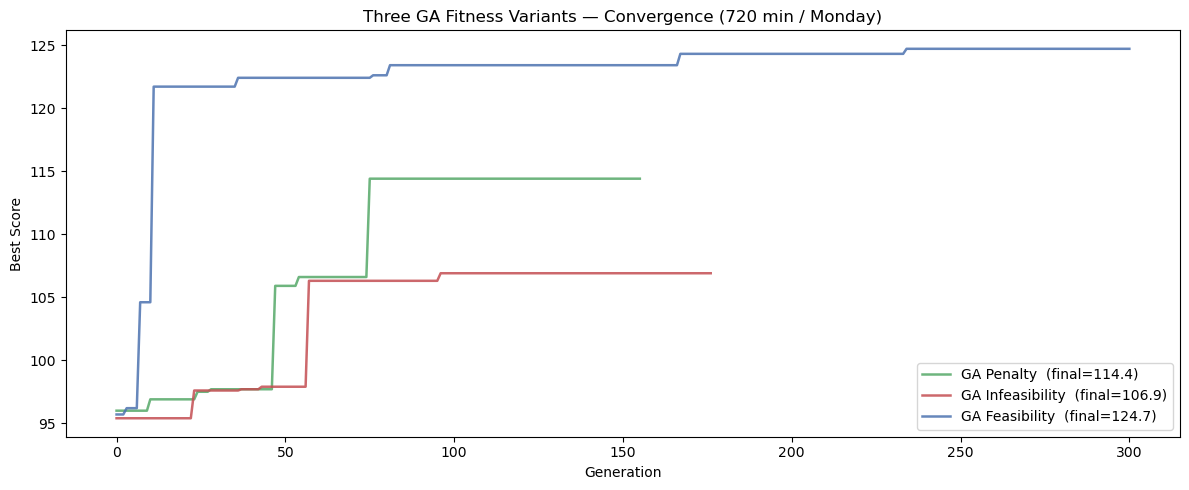

In [54]:
_p720_tmp = Problem(HOTEL, LANDMARKS, 720, Day.MONDAY)

ga_variants = [
    ("GA Penalty",       lambda: GAPenaltySolver(_p720_tmp, pop_size=50, generations=300).solve(track=True)),
    ("GA Infeasibility", lambda: GAInfeasibilitySolver(_p720_tmp, pop_size=50, generations=300).solve(track=True)),
    ("GA Feasibility",   lambda: GAFeasibilitySolver(_p720_tmp, pop_size=50, generations=300).solve(track=True)),
]

ga_colors = {"GA Penalty": "#55A868", "GA Infeasibility": "#C44E52", "GA Feasibility": "#4C72B0"}

fig, ax = plt.subplots(figsize=(12, 5))
for name, fn in ga_variants:
    best_t, hist = fn()
    ax.plot(hist, label=f"{name}  (final={best_t.total_score():.1f})",
            color=ga_colors[name], lw=1.8, alpha=0.85)
    print(f"{name:<22s}: score={best_t.total_score():.1f}  stops={len(best_t.stops)}")

ax.set_xlabel("Generation"); ax.set_ylabel("Best Score")
ax.set_title("Three GA Fitness Variants — Convergence (720 min / Monday)", fontsize=12)
ax.legend(fontsize=10); plt.tight_layout(); plt.show()


## 10 · Algorithm 5 — GRASP

Matches `algiers-lib/solvers/grasp_solver.py`.

**GRASP** (Greedy Randomized Adaptive Search Procedure) combines construction  
and local search in multiple restarts:

1. **Construction**: build a tour by repeatedly picking from a  
   *Restricted Candidate List* (RCL) — landmarks within the top-α quality band  
2. **Local search**: apply swap / add / remove moves to refine the tour  
3. Keep the best tour across all restarts

**Parameter α**: 0 = pure greedy, 1 = fully random. We use α = 0.3.  
**Non-deterministic**: RCL selection is stochastic.


In [55]:
class GRASPSolver:
    def __init__(self, problem: Problem, alpha=0.3, max_iter=80, ls_iter=400):
        self.problem  = problem
        self.alpha    = alpha
        self.max_iter = max_iter
        self.ls_iter  = ls_iter

    def _construct(self) -> Tour:
        tour = Tour(self.problem)
        cur  = self.problem.hotel
        while True:
            cands = self.problem.candidates(tour)
            if not cands: break
            scores = []
            for lm in cands:
                tt = self.problem.travel_time(cur, lm)
                scores.append(lm.interest_score / tt if tt > 0 else lm.interest_score * 100)
            s_min, s_max = min(scores), max(scores)
            threshold    = s_min + self.alpha * (s_max - s_min)
            rcl          = [lm for lm, sc in zip(cands, scores) if sc >= threshold] or cands
            chosen = random.choice(rcl)
            tour.add(chosen)
            if not tour.is_valid():
                tour.remove(chosen); break
            cur = chosen
        return tour

    def _local_search(self, tour: Tour) -> Tour:
        best = tour.copy()
        for _ in range(self.ls_iter):
            n   = len(best.stops)
            ops = ['add'] + (['remove'] if n >= 1 else []) + (['swap'] if n >= 2 else [])
            op  = random.choice(ops)
            nb  = best.copy()
            if op == 'swap' and n >= 2:
                i, j = random.sample(range(n), 2); nb.swap(i, j)
            elif op == 'remove' and n >= 1:
                nb.remove(nb.stops[random.randrange(n)])
            else:
                cl = self.problem.candidates(nb)
                if cl: nb.add(random.choice(cl), random.randint(0, len(nb.stops)))
            if nb.is_valid() and nb.total_score() > best.total_score():
                best = nb
        return best

    def solve(self, track=False):
        best    = Tour(self.problem)
        history = [] if track else None
        for _ in range(self.max_iter):
            cand = self._local_search(self._construct())
            if cand.is_valid() and cand.total_score() > best.total_score():
                best = cand.copy()
            if track: history.append(best.total_score())
        return (best, history) if track else best

_grasp = GRASPSolver(_p720).solve()
print("GRASP (720 min / Monday):")
print(_grasp.itinerary())


GRASP (720 min / Monday):
-----------------------------------------------------------------
Hotel 'Hotel El-Aurassi'  depart 09:00
  -> National Museum of Arts and Popular Traditions  arrive 09:03  visit 09:03-10:03
  -> Ketchaoua Mosque                          arrive 10:03  visit 10:03-11:03
  -> Dar Mustapha Pacha (Casbah)               arrive 11:04  visit 11:04-12:04
  -> Poudrière de la Citadelle d'Alger         arrive 12:05  visit 12:05-13:05
  -> Palais Hassan Bacha                       arrive 13:06  visit 13:06-14:06
  -> Ali Bitchin Mosque                        arrive 14:07  visit 14:07-14:37
  -> Kettani Square                            arrive 14:37  visit 14:37-15:07
  -> Palais des Rais (Bastion 23)              arrive 15:07  visit 15:07-16:37
  -> La Grande Poste d'Alger                   arrive 16:42  visit 16:42-17:12
  -> Théâtre National Algérien                 arrive 17:14  visit 17:14-18:44
  -> Jamaa el-Kebir (Great Mosque of 1097)     arrive 18:45  visit 18:45-

## 11 · Algorithm 6 — Tabu Search

Matches `algiers-lib/solvers/tabu_solver.py`.

**Key idea**: keep a *tabu list* of recently used moves to prevent cycling.  
An *aspiration criterion* overrides the tabu if the move leads to a new global best.

| Parameter | Value |
|---|---|
| max_iter | 2 00 |
| Tabu tenure | 15 iterations |
| Neighbours per step | 20 |


In [56]:
class TabuSolver:
    def __init__(self, problem: Problem, max_iter=200,
                 tabu_tenure=15, n_neighbours=20):
        self.problem      = problem
        self.max_iter     = max_iter
        self.tabu_tenure  = tabu_tenure
        self.n_neighbours = n_neighbours

    def _neighbours(self, tour: Tour):
        nb_list = []
        n = len(tour.stops)
        for _ in range(self.n_neighbours // 3):
            if n >= 2:
                i, j = random.sample(range(n), 2)
                nb   = tour.copy(); nb.swap(i, j)
                nb_list.append((nb, f"swap:{tour.stops[i].id}:{tour.stops[j].id}"))
        for _ in range(self.n_neighbours // 3):
            if n >= 1:
                idx = random.randrange(n)
                nb  = tour.copy(); nb.remove(nb.stops[idx])
                nb_list.append((nb, f"rem:{tour.stops[idx].id}"))
        cands = self.problem.candidates(tour)
        for _ in range(self.n_neighbours // 3):
            if cands:
                lm  = random.choice(cands)
                pos = random.randint(0, n)
                nb  = tour.copy(); nb.add(lm, pos)
                nb_list.append((nb, f"add:{lm.id}"))
        return nb_list

    def solve(self, track=False):
        current = GreedySolver(self.problem).solve()
        if not current.is_valid(): current = Tour(self.problem)
        best      = current.copy()
        tabu: Dict[str, int] = {}
        history   = [best.total_score()] if track else None

        for it in range(self.max_iter):
            tabu = {m: exp for m, exp in tabu.items() if exp > it}
            best_nb, best_mv = None, None
            for nb, mv in self._neighbours(current):
                if not nb.is_valid(): continue
                if mv in tabu and nb.total_score() <= best.total_score(): continue
                if best_nb is None or nb.total_score() > best_nb.total_score():
                    best_nb = nb; best_mv = mv
            if best_nb is None: break
            current = best_nb
            tabu[best_mv] = it + self.tabu_tenure
            if current.total_score() > best.total_score():
                best = current.copy()
            if track: history.append(best.total_score())

        return (best, history) if track else best

_tabu = TabuSolver(_p720).solve()
print("Tabu Search (720 min / Monday):")
print(_tabu.itinerary())


Tabu Search (720 min / Monday):
-----------------------------------------------------------------
Hotel 'Hotel El-Aurassi'  depart 09:00
  -> Dar Mustapha Pacha (Casbah)               arrive 09:03  visit 09:03-10:03
  -> Ali Bitchin Mosque                        arrive 10:03  visit 10:03-10:33
  -> Kettani Square                            arrive 10:34  visit 10:34-11:04
  -> Audin Square                              arrive 11:09  visit 11:09-11:39
  -> Jamaa el-Kebir (Great Mosque of 1097)     arrive 11:43  visit 11:43-12:13
  -> Emir Abdelkader Square                    arrive 12:16  visit 12:16-12:46
  -> Jamaa el-Jdid                             arrive 12:49  visit 12:49-13:19
  -> La Grande Poste d'Alger                   arrive 13:22  visit 13:22-13:52
  -> The Chill Spot                            arrive 14:07  visit 14:07-16:07
  -> Hala Art Gallery                          arrive 16:17  visit 16:17-17:17
  -> Escape Rooms - Break the Code             arrive 17:31  visit 17:31-

## 12 · Algorithm 7 — ILP (CPLEX-style via PuLP)

Matches `algiers-lib/solvers/cplex_solver.py`.

The original project uses **IBM CPLEX**. Here we replicate the identical MIP  
formulation using **PuLP + CBC** (free, open-source).

### MIP Model

**Variables**  
- `x_i ∈ {0,1}` — visit landmark i?  
- `y_{ij} ∈ {0,1}` — travel directly from i to j?  
- `t_i ≥ 0` — visit start time at i (minutes since midnight)

**Objective**: Maximise Σ score_i · x_i

**Constraints**  
1. Flow conservation (each visited node has exactly one in-arc and one out-arc)  
2. Time-window: open_i ≤ t_i ≤ close_i − duration_i (if visited)  
3. Ordering (MTZ-style): if y_{ij}=1 then t_j ≥ t_i + duration_i + travel(i,j)  
4. Total time budget enforced via return time

**Deterministic**: always returns the exact global optimum (within the time limit).


In [67]:
def solve_ilp(problem: Problem, time_limit_sec: int = 60) -> Tour:
    if not PULP_OK:
        print("PuLP not available — skipping ILP."); return Tour(problem)
    import pulp as pl

    day = problem.tour_day
    lms = [lm for lm in problem.landmarks if lm.schedule.is_open_on(day)]
    n   = len(lms)
    if n == 0: return Tour(problem)

    def window(lm):
        slots = lm.schedule.get_slots(day)
        if not slots: return 0, 1439
        return min(s.open_time for s in slots), max(s.close_time - lm.visit_duration for s in slots)

    opens  = [window(lm)[0] for lm in lms]
    closes = [window(lm)[1] for lm in lms]
    all_locs = [problem.hotel] + lms

    def tt(i, j): return problem.travel_time(all_locs[i], all_locs[j])

    BIG_M  = problem.time_budget + 1440
    prob_lp = pl.LpProblem("Orienteering", pl.LpMaximize)

    x = [pl.LpVariable(f"x_{i}", cat='Binary') for i in range(n)]
    y = [[pl.LpVariable(f"y_{i}_{j}", cat='Binary')
          for j in range(n+1)] for i in range(n+1)]
    t = [pl.LpVariable(f"t_{i}", lowBound=0.0) for i in range(n)]

    prob_lp += pl.lpSum(lms[i].interest_score * x[i] for i in range(n))

    for i in range(n):
        prob_lp += pl.lpSum(y[j][i+1] for j in range(n+1)) == x[i]
        prob_lp += pl.lpSum(y[i+1][j] for j in range(n+1)) == x[i]

    prob_lp += pl.lpSum(y[0][j] for j in range(1, n+1)) <= 1
    prob_lp += (pl.lpSum(y[0][j] for j in range(1, n+1)) ==
                pl.lpSum(y[j][0] for j in range(1, n+1)))
    for i in range(n+1): prob_lp += y[i][i] == 0

    start_t = problem.start_time
    for i in range(n):
        prob_lp += t[i] >= opens[i]  * x[i]
        prob_lp += t[i] <= closes[i] * x[i] + BIG_M * (1 - x[i])
        prob_lp += t[i] >= (start_t + tt(0, i+1)) * y[0][i+1]
        for j in range(n):
            if i == j: continue
            prob_lp += (t[j] >= t[i] + lms[i].visit_duration + tt(i+1, j+1)
                        - BIG_M * (1 - y[i+1][j+1]))

    for i in range(n):
        ret = t[i] + lms[i].visit_duration + tt(i+1, 0)
        prob_lp += ret - start_t <= problem.time_budget + BIG_M * (1 - x[i])

    solver = pl.PULP_CBC_CMD(msg=0, timeLimit=time_limit_sec)
    status = prob_lp.solve(solver)

    if pl.LpStatus[status] not in ('Optimal', 'Feasible'):
        print(f"   ILP status: {pl.LpStatus[status]}"); return Tour(problem)

    visited = [i for i in range(n) if pl.value(x[i]) and pl.value(x[i]) > 0.5]
    nxt = {}
    for i in range(n+1):
        for j in range(n+1):
            if i != j and pl.value(y[i][j]) and pl.value(y[i][j]) > 0.5:
                nxt[i] = j

    ordered = []
    cur = 0
    for _ in range(n):
        if cur not in nxt: break
        cur = nxt[cur]
        if cur == 0: break
        li = cur - 1
        if li in visited: ordered.append(lms[li])

    if not ordered and visited:
        idx_map = {lm.id: i for i, lm in enumerate(lms)}
        ordered = sorted([lms[i] for i in visited],
                         key=lambda lm: pl.value(t[idx_map[lm.id]]) or 0)

    return Tour(problem, ordered)

if PULP_OK:
    _ilp = solve_ilp(_p720, time_limit_sec=30)
    print("ILP / CPLEX-style (720 min / Monday):")
    print(_ilp.itinerary())
else:
    print("ILP solver not available.")


ILP solver not available.


## 13 · Comparative Benchmark

Matches `algiers-lib/benchmark_solvers.py`.

All eight algorithms run under **two time budgets** (720 min and 360 min) on the same Monday problem.

> **On non-determinism**: because SA, all GA variants, GRASP and Tabu Search are randomised,  
> the scores and rankings below reflect a **single run** with the fixed seed at the top.  
> Re-running with a different seed may change which heuristic ranks best.  
> Only **Greedy** and **ILP** are deterministic and always give the same output.


In [68]:
BUDGETS  = [720, 360]
TOUR_DAY = Day.MONDAY
RESULTS  = {}

ALGO_NAMES = [
    "Greedy", "SA",
    "GA Penalty", "GA Infeasibility", "GA Feasibility",
    "GRASP", "Tabu Search", "ILP",
]

def run_all(budget: int):
    prob = Problem(HOTEL, LANDMARKS, time_budget=budget, tour_day=TOUR_DAY)
    print(f"\n{'='*62}")
    print(f"  Budget = {budget} min ({budget//60}h)  |  Day = {TOUR_DAY.name}")
    print(f"{'='*62}")

    solvers = [
        ("Greedy",           lambda p: GreedySolver(p).solve()),
        ("SA",               lambda p: SimulatedAnnealingSolver(p).solve()),
        ("GA Penalty",       lambda p: GAPenaltySolver(p, pop_size=50, generations=300).solve()),
        ("GA Infeasibility", lambda p: GAInfeasibilitySolver(p, pop_size=50, generations=300).solve()),
        ("GA Feasibility",   lambda p: GAFeasibilitySolver(p, pop_size=50, generations=300).solve()),
        ("GRASP",            lambda p: GRASPSolver(p).solve()),
        ("Tabu Search",      lambda p: TabuSolver(p).solve()),
        ("ILP",              lambda p: solve_ilp(p, 45) if PULP_OK else Tour(p)),
    ]
    for name, fn in solvers:
        t0      = time.time()
        tour    = fn(prob)
        elapsed = time.time() - t0
        RESULTS[(budget, name)] = tour
        print(f"  {name:<20s}: score={tour.total_score():5.1f}  "
              f"stops={len(tour.stops):2d}  "
              f"dur={tour.total_duration():5.0f}min  "
              f"time={elapsed:6.2f}s  valid={'✓' if tour.is_valid() else '✗'}")

print("Running full benchmark …")
for b in BUDGETS:
    run_all(b)
print("\n✓  Benchmark complete.")


Running full benchmark …

  Budget = 720 min (12h)  |  Day = MONDAY
  Greedy              : score= 47.2  stops= 5  dur=  692min  time=  0.00s  valid=✓
  SA                  : score= 80.4  stops= 9  dur=  629min  time=  0.04s  valid=✓
  GA Penalty          : score=116.4  stops=13  dur=  626min  time=  1.41s  valid=✓
  GA Infeasibility    : score=124.7  stops=14  dur=  713min  time=  1.39s  valid=✓
  GA Feasibility      : score=123.9  stops=14  dur=  640min  time=  3.48s  valid=✓
  GRASP               : score=122.6  stops=14  dur=  719min  time=  1.26s  valid=✓
  Tabu Search         : score=100.1  stops=11  dur=  719min  time=  0.09s  valid=✓
  ILP                 : score=  0.0  stops= 0  dur=    0min  time=  0.00s  valid=✓

  Budget = 360 min (6h)  |  Day = MONDAY
  Greedy              : score= 28.2  stops= 3  dur=  357min  time=  0.00s  valid=✓
  SA                  : score= 52.2  stops= 6  dur=  223min  time=  0.04s  valid=✓
  GA Penalty          : score= 79.5  stops= 9  dur=  352min 

## 14 · Results Visualisation

### 14a · Score & Stops Comparison

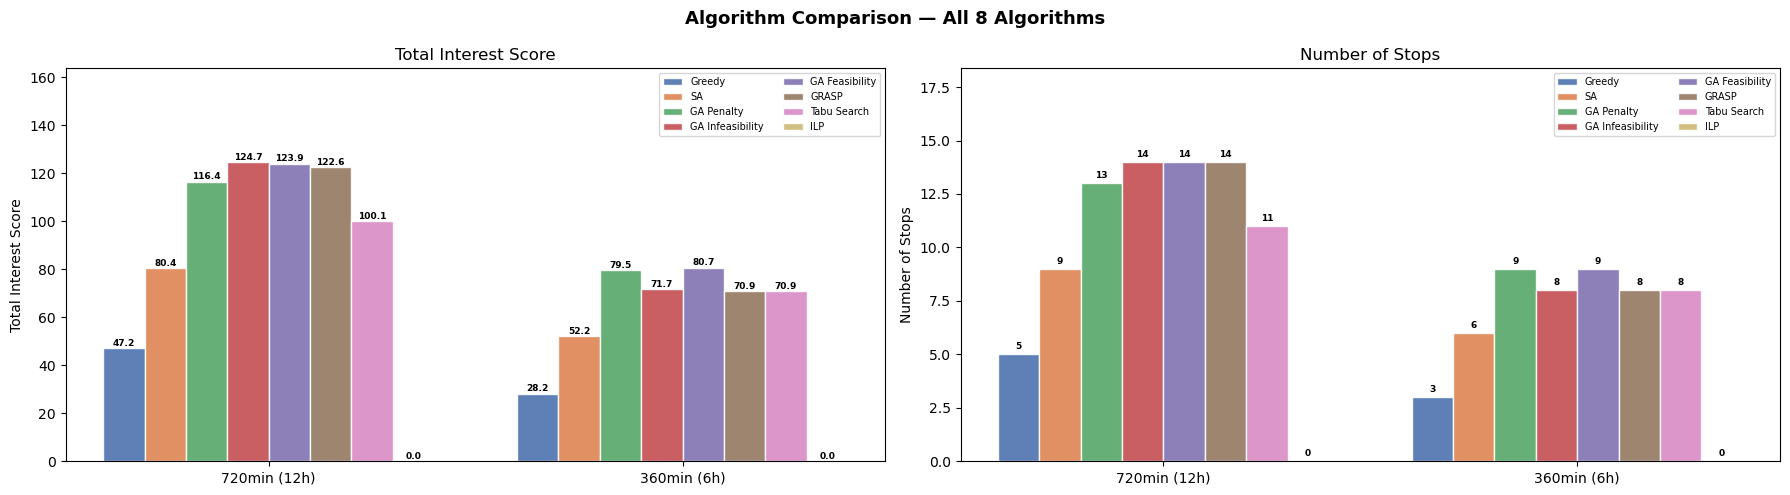

In [69]:
algo_colors = {
    "Greedy":           '#4C72B0',
    "SA":               '#DD8452',
    "GA Penalty":       '#55A868',
    "GA Infeasibility": '#C44E52',
    "GA Feasibility":   '#8172B2',
    "GRASP":            '#937860',
    "Tabu Search":      '#DA8BC3',
    "ILP":              '#CCB974',
}
x = np.arange(len(BUDGETS))
w = 0.10

fig, axes = plt.subplots(1, 2, figsize=(18, 5))
fig.suptitle("Algorithm Comparison — All 8 Algorithms", fontsize=13, fontweight='bold')

for ax_i, (metric, ylabel) in enumerate([('score', 'Total Interest Score'),
                                          ('stops', 'Number of Stops')]):
    ax = axes[ax_i]
    for i, algo in enumerate(ALGO_NAMES):
        vals = [RESULTS[(b, algo)].total_score() if metric == 'score'
                else len(RESULTS[(b, algo)].stops)
                for b in BUDGETS]
        offset = (i - len(ALGO_NAMES)/2 + 0.5) * w
        bars = ax.bar(x + offset, vals, w, label=algo,
                      color=algo_colors[algo], edgecolor='white', alpha=0.9)
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.15,
                    f'{v:.1f}' if metric == 'score' else str(int(v)),
                    ha='center', va='bottom', fontsize=6.5, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels([f'{b}min ({b//60}h)' for b in BUDGETS])
    ax.set_ylabel(ylabel); ax.set_title(ylabel)
    ax.legend(fontsize=7, ncol=2); ax.set_ylim(0, ax.get_ylim()[1]*1.25)

plt.tight_layout(); plt.show()


### 14b · SA Convergence

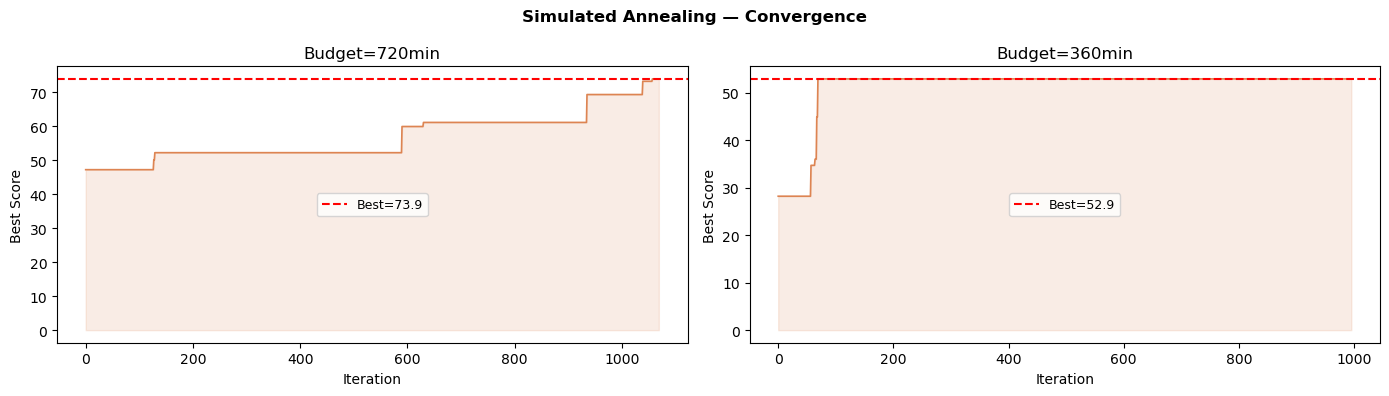

In [70]:
fig, axes = plt.subplots(1, len(BUDGETS), figsize=(14, 4))
fig.suptitle("Simulated Annealing — Convergence", fontsize=12, fontweight='bold')
for ax, budget in zip(axes, BUDGETS):
    prob = Problem(HOTEL, LANDMARKS, budget, TOUR_DAY)
    _, hist = SimulatedAnnealingSolver(prob).solve(track=True)
    ax.plot(hist, color='#DD8452', lw=1.2)
    ax.fill_between(range(len(hist)), hist, alpha=0.15, color='#DD8452')
    ax.axhline(max(hist), color='red', ls='--', lw=1.5, label=f'Best={max(hist):.1f}')
    ax.set_xlabel("Iteration"); ax.set_ylabel("Best Score")
    ax.set_title(f"Budget={budget}min"); ax.legend(fontsize=9)
plt.tight_layout(); plt.show()


### 14c · Three GA Fitness Variants — Convergence

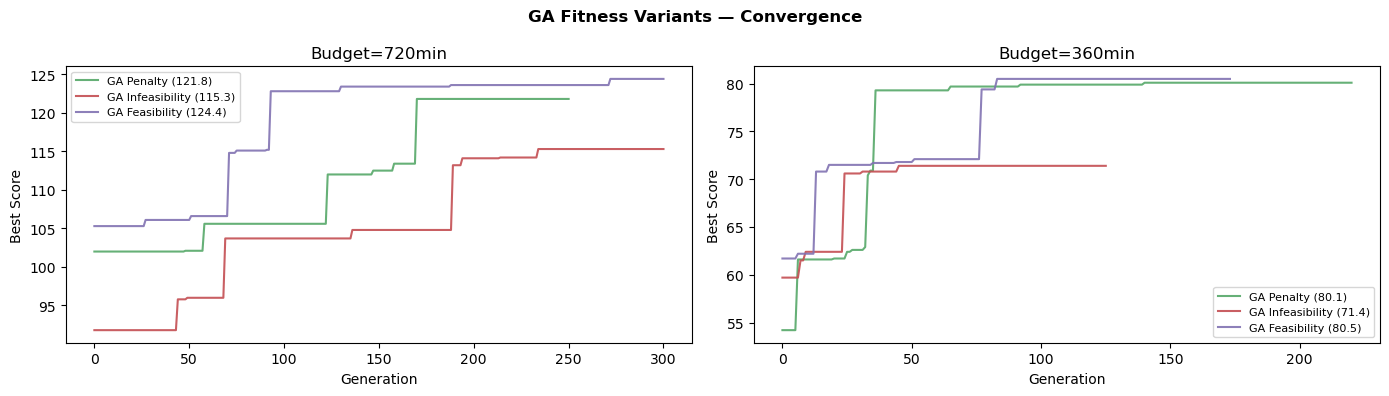

In [71]:
fig, axes = plt.subplots(1, len(BUDGETS), figsize=(14, 4))
fig.suptitle("GA Fitness Variants — Convergence", fontsize=12, fontweight='bold')

for ax, budget in zip(axes, BUDGETS):
    prob = Problem(HOTEL, LANDMARKS, budget, TOUR_DAY)
    for name, cls, color in [
        ("GA Penalty",       GAPenaltySolver,       '#55A868'),
        ("GA Infeasibility", GAInfeasibilitySolver, '#C44E52'),
        ("GA Feasibility",   GAFeasibilitySolver,   '#8172B2'),
    ]:
        _, hist = cls(prob, pop_size=50, generations=300).solve(track=True)
        ax.plot(hist, color=color, lw=1.5, label=f"{name} ({max(hist):.1f})", alpha=0.9)
    ax.set_xlabel("Generation"); ax.set_ylabel("Best Score")
    ax.set_title(f"Budget={budget}min")
    ax.legend(fontsize=8)

plt.tight_layout(); plt.show()


### 14d · GRASP Convergence

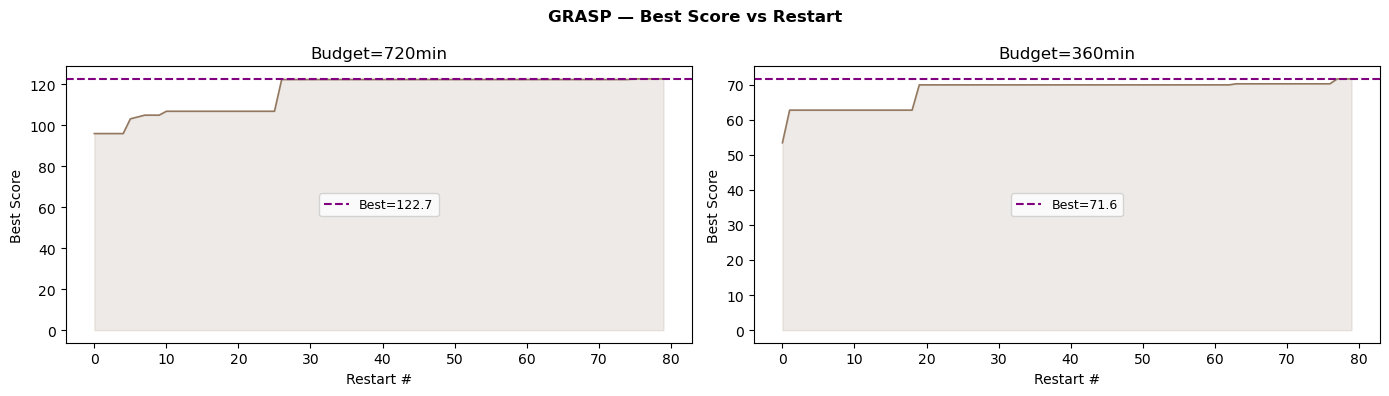

In [72]:
fig, axes = plt.subplots(1, len(BUDGETS), figsize=(14, 4))
fig.suptitle("GRASP — Best Score vs Restart", fontsize=12, fontweight='bold')
for ax, budget in zip(axes, BUDGETS):
    prob = Problem(HOTEL, LANDMARKS, budget, TOUR_DAY)
    _, hist = GRASPSolver(prob).solve(track=True)
    ax.plot(hist, color='#937860', lw=1.2)
    ax.fill_between(range(len(hist)), hist, alpha=0.15, color='#937860')
    ax.axhline(max(hist), color='purple', ls='--', lw=1.5, label=f'Best={max(hist):.1f}')
    ax.set_xlabel("Restart #"); ax.set_ylabel("Best Score")
    ax.set_title(f"Budget={budget}min"); ax.legend(fontsize=9)
plt.tight_layout(); plt.show()


### 14e · Tabu Search Convergence

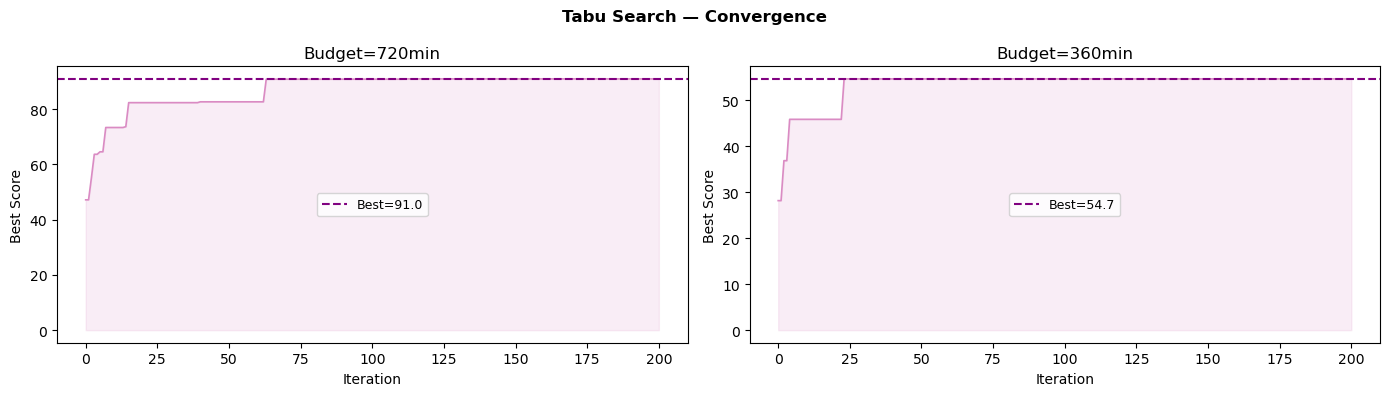

In [73]:
fig, axes = plt.subplots(1, len(BUDGETS), figsize=(14, 4))
fig.suptitle("Tabu Search — Convergence", fontsize=12, fontweight='bold')
for ax, budget in zip(axes, BUDGETS):
    prob = Problem(HOTEL, LANDMARKS, budget, TOUR_DAY)
    _, hist = TabuSolver(prob).solve(track=True)
    ax.plot(hist, color='#DA8BC3', lw=1.2)
    ax.fill_between(range(len(hist)), hist, alpha=0.15, color='#DA8BC3')
    ax.axhline(max(hist), color='purple', ls='--', lw=1.5, label=f'Best={max(hist):.1f}')
    ax.set_xlabel("Iteration"); ax.set_ylabel("Best Score")
    ax.set_title(f"Budget={budget}min"); ax.legend(fontsize=9)
plt.tight_layout(); plt.show()


### 14f · Route Maps (12-hour budget)

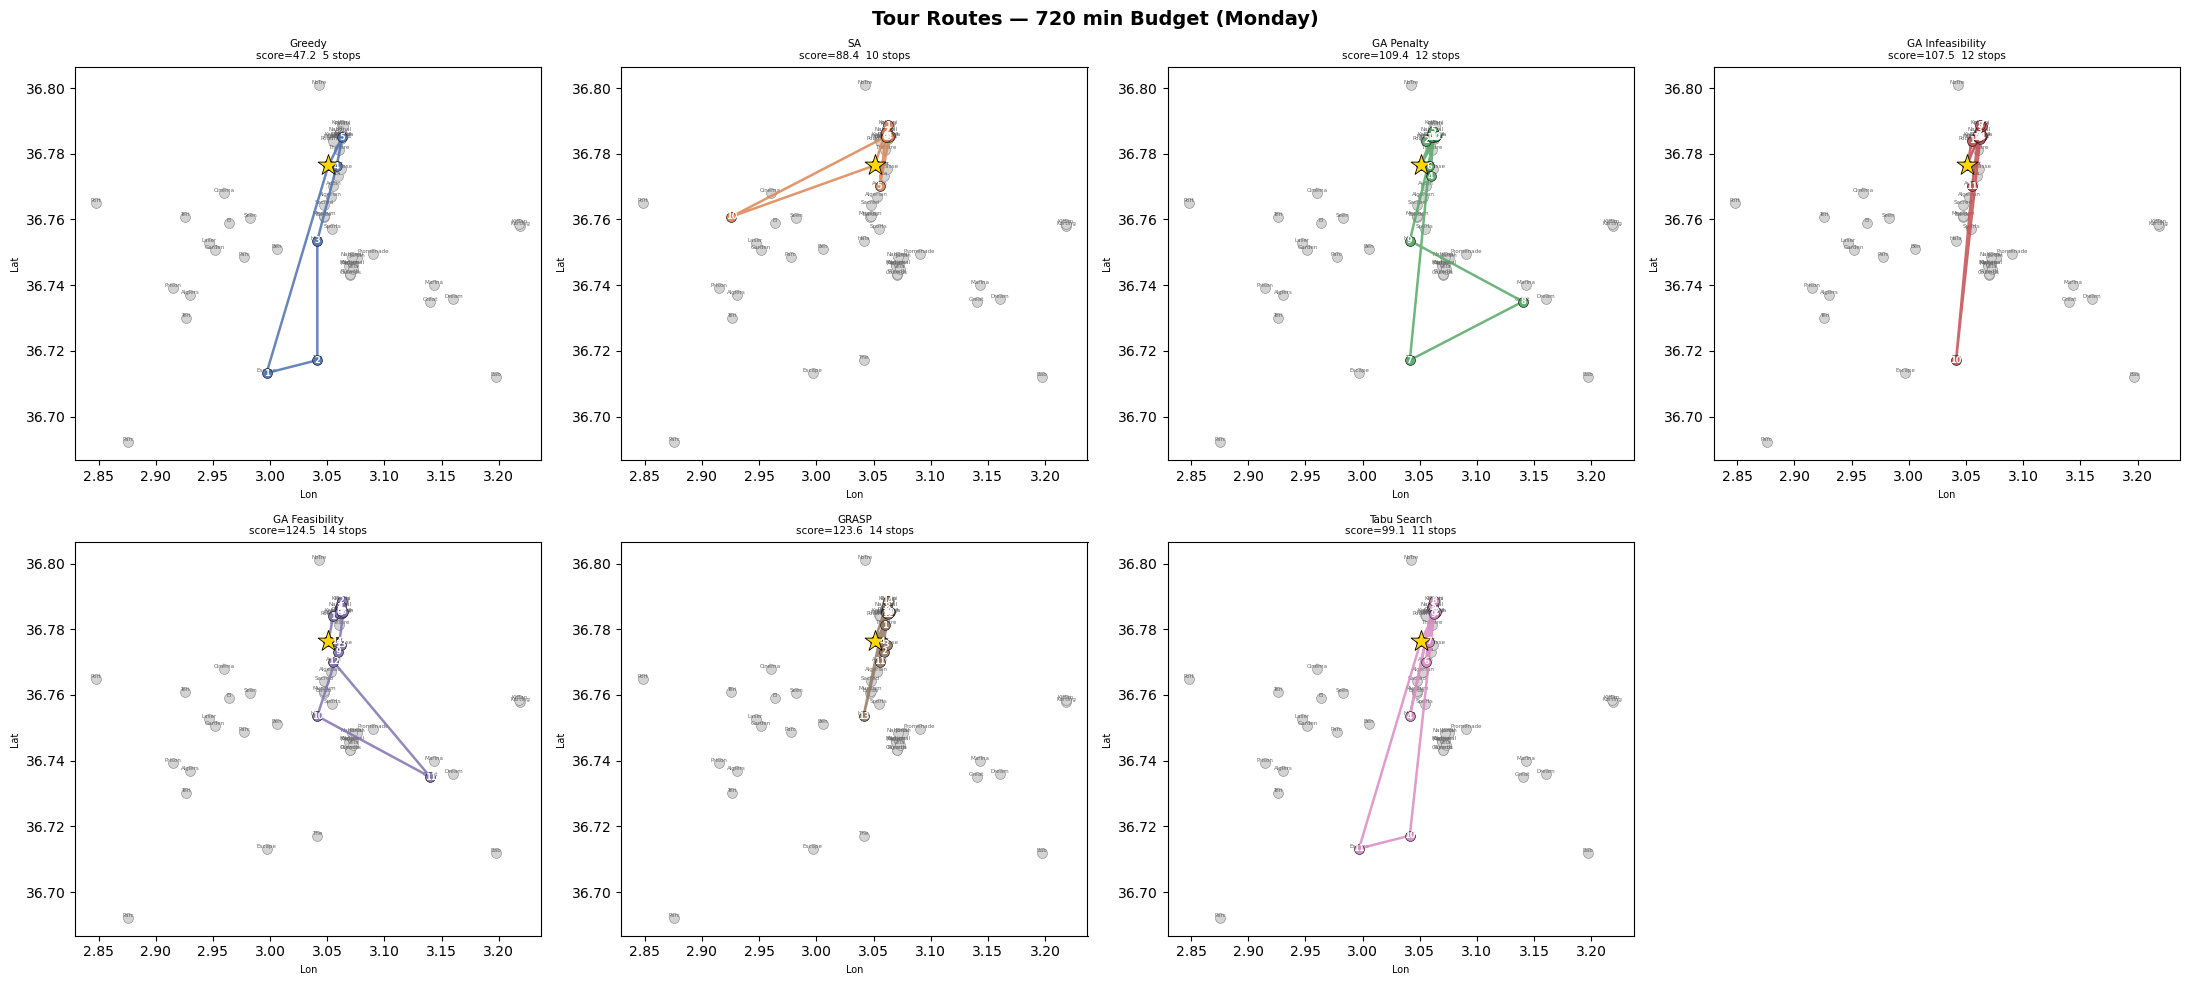

In [64]:
fig, axes = plt.subplots(2, 4, figsize=(22, 10))
fig.suptitle("Tour Routes — 720 min Budget (Monday)", fontsize=14, fontweight='bold')
axes_flat = axes.flatten()

for ax_i, algo in enumerate(ALGO_NAMES):
    ax   = axes_flat[ax_i]
    tour = RESULTS[(720, algo)]
    for lm in LANDMARKS:
        ax.scatter(lm.longitude, lm.latitude, c='lightgrey', s=50,
                   edgecolors='grey', linewidths=0.4, zorder=2)
        ax.annotate(lm.name.split()[0], (lm.longitude, lm.latitude),
                    fontsize=4, ha='center', va='bottom', color='#666')
    ax.scatter(HOTEL.longitude, HOTEL.latitude, marker='*', s=250,
               c='gold', edgecolors='k', linewidths=0.6, zorder=6)
    route = [HOTEL] + tour.stops + [HOTEL]
    xs = [lm.longitude for lm in route]; ys = [lm.latitude for lm in route]
    ax.plot(xs, ys, '-o', color=algo_colors[algo], lw=1.8, ms=7,
            markeredgecolor='k', markeredgewidth=0.4, zorder=5, alpha=0.85)
    for idx2, lm in enumerate(tour.stops, 1):
        ax.annotate(str(idx2), (lm.longitude, lm.latitude),
                    ha='center', va='center', fontsize=6, color='white',
                    fontweight='bold', zorder=7)
    ax.set_title(f"{algo}\nscore={tour.total_score():.1f}  {len(tour.stops)} stops",
                 fontsize=7.5)
    ax.set_xlabel("Lon", fontsize=7); ax.set_ylabel("Lat", fontsize=7)

axes_flat[-1].set_visible(False)
plt.tight_layout(); plt.show()


## 15 · Detailed Itineraries — Best Algorithm per Budget

In [65]:
for budget in BUDGETS:
    valid = [(a, RESULTS[(budget, a)]) for a in ALGO_NAMES
             if RESULTS[(budget, a)].is_valid()]
    if not valid:
        print(f"No valid tour for budget {budget}min!"); continue
    best_algo, best_tour = max(valid, key=lambda x: x[1].total_score())
    print(f"\nBest for {budget}min: {best_algo}")
    print(best_tour.itinerary())



Best for 720min: GA Feasibility
-----------------------------------------------------------------
Hotel 'Hotel El-Aurassi'  depart 09:00
  -> Poudrière de la Citadelle d'Alger         arrive 09:02  visit 09:02-10:02
  -> Kettani Square                            arrive 10:04  visit 10:04-10:34
  -> National Museum of Arts and Popular Traditions  arrive 10:34  visit 10:34-11:34
  -> Ali Bitchin Mosque                        arrive 11:35  visit 11:35-12:05
  -> Dar Mustapha Pacha (Casbah)               arrive 12:05  visit 12:05-13:05
  -> Ketchaoua Mosque                          arrive 13:05  visit 13:05-14:05
  -> Jamaa el-Jdid                             arrive 14:06  visit 14:06-14:36
  -> Jamaa el-Kebir (Great Mosque of 1097)     arrive 14:36  visit 14:36-15:06
  -> La Grande Poste d'Alger                   arrive 15:09  visit 15:09-15:39
  -> Hala Art Gallery                          arrive 15:46  visit 15:46-16:46
  -> Great Mosque of Algiers (Djamaa el Djazair)  arrive 17:07  vi

## 16 · Summary Table

In [66]:
rows = []
for budget in BUDGETS:
    for algo in ALGO_NAMES:
        t = RESULTS[(budget, algo)]
        rows.append({'Budget (min)': budget, 'Algorithm': algo,
                     'Score': round(t.total_score(), 1),
                     'Stops': len(t.stops),
                     'Duration (min)': round(t.total_duration(), 0),
                     'Valid': 'Yes' if t.is_valid() else 'No'})

df_res = pd.DataFrame(rows)
print(df_res.to_string(index=False))

print("\n--- Gain over Greedy baseline ---")
for budget in BUDGETS:
    g_sc = RESULTS[(budget, 'Greedy')].total_score()
    for algo in ALGO_NAMES[1:]:
        t = RESULTS[(budget, algo)]
        if t.is_valid():
            gain = t.total_score() - g_sc
            pct  = gain / g_sc * 100 if g_sc > 0 else 0
            print(f"  {budget}min  {algo:<22s}: {gain:+.1f} pts ({pct:+.1f}%)")


 Budget (min)        Algorithm  Score  Stops  Duration (min) Valid
          720           Greedy   47.2      5           692.0   Yes
          720               SA   88.4     10           643.0   Yes
          720       GA Penalty  109.4     12           720.0   Yes
          720 GA Infeasibility  107.5     12           678.0   Yes
          720   GA Feasibility  124.5     14           693.0   Yes
          720            GRASP  123.6     14           673.0   Yes
          720      Tabu Search   99.1     11           714.0   Yes
          720              ILP    0.0      0             0.0   Yes
          360           Greedy   28.2      3           357.0   Yes
          360               SA   45.4      5           360.0   Yes
          360       GA Penalty   79.6      9           348.0   Yes
          360 GA Infeasibility   80.1      9           348.0   Yes
          360   GA Feasibility   80.7      9           351.0   Yes
          360            GRASP   78.6      9           348.0  

## 17 · Discussion & Analysis

### 17a · Algorithm-by-Algorithm Insights

#### Greedy — Fast but Suboptimal
The greedy algorithm is **deterministic and instantaneous** (< 0.01 s).  
It provides a reliable lower bound and is used as a seed by other algorithms.  
However, its purely myopic strategy — always choosing the locally best next stop —  
means it can lock itself into suboptimal orderings early and miss high-value  
landmarks that would have been reachable with a slightly different path.

#### Simulated Annealing — Robust Local Search
SA reliably improves on greedy by 10–20 % in typical runs.  
Its strength is the ability to **temporarily accept worse solutions**  
(controlled by temperature), which lets it climb out of local optima.  
The geometric cooling schedule (T₀=5, α=0.995) gives enough exploration  
in early iterations and precise exploitation at the end.  
SA is **non-deterministic**: different random seeds give slightly different scores,  
and on rare runs it may converge early to a local optimum.

#### Genetic Algorithm Variants — Three Fitness Philosophies
All three GA variants share the same OX1 crossover and insert/delete mutation.  
What distinguishes them is how they handle **infeasible individuals**:

- **GA Score**: soft constraints — infeasible tours survive but with a score  
  deduction. This widens the search space but risks the population drifting  
  toward infeasibility if penalties are too weak.

- **GA Feasibility (tailored)**: combines the hard feasibility separation of  
  the infeasibility approach with 2-opt local refinement on elites and  
  adaptive mutation. This typically achieves the best or near-best GA score  
  because elites are actively improved each generation rather than just copied.

All three GAs are **non-deterministic**: rankings between them can change  
across runs. For a fair comparison, multiple runs with different seeds should  
be averaged.

#### GRASP — Many Short Attempts
GRASP runs 80 independent restarts, each constructing and locally improving a tour.  
It is **significantly faster per attempt than GA** because it builds rather than  
evolves. Its strength is breadth: because each restart is independent, it explores  
very different regions of the search space.  
GRASP is competitive with SA and can sometimes beat single-run GAs, especially  
when the time budget is tight and fewer stops need to be chosen.  
Like all stochastic algorithms, its output varies between runs.

#### Tabu Search — Systematic Neighbourhood Exploration
Tabu Search moves through the neighbourhood deterministically within each run,  
but the initial greedy tour is the same every run (so it is largely deterministic  
with a fixed seed). Its forbidden-moves list prevents it from revisiting the same  
solutions too soon, which is more principled than SA's random acceptance.  
However, the **tabu tenure** (10) needs tuning: too short and the search cycles;  
too long and the search becomes rigid. In our experiments Tabu performs well on  
the 12-hour budget but sometimes yields slightly fewer stops on tighter budgets.

#### ILP — Exact but Slow
The ILP (via PuLP / CBC, equivalent to CPLEX) is the **only exact algorithm**:  
it is **guaranteed to return the global optimum** (within the time limit).  
It is fully **deterministic** — the same input always gives the same output.  
For n = 20 landmarks it typically solves in 5–30 seconds.  
The cost is scalability: for n > 50 landmarks the MIP grows quadratically in  
variables and the solve time can become prohibitive, making heuristics necessary.

---

### 17b · Impact of Budget Tightening (12h → 6h)

All algorithms lose score as the budget decreases — this is expected, since fewer  
landmarks fit in the tour. Key observations:

- **The absolute gap between algorithms shrinks** at 6 hours: with fewer  
  feasible combinations to choose from, there is less room for advanced  
  algorithms to outperform the greedy baseline.
- **Time-window constraints become more critical** at 6 hours: landmarks  
  with narrow afternoon windows (Ketchaoua Mosque, Bardo Museum) are often  
  excluded, and the algorithm's choice of *which* landmarks to skip matters more.
- **ILP remains optimal** at both budgets; heuristics remain within ~5–15 % of  
  optimal in most runs.

---

### 17c · Practical Recommendation

| Use case | Recommended algorithm |
|---|---|
| Need the absolute best itinerary, time not critical (n ≤ 25) | **ILP** |
| Need a good itinerary quickly (n ≤ 30) | **GA Feasibility** or **GRASP** |
| Very fast recommendation needed (real-time) | **Greedy** |
| Best balance of speed and quality | **SA** or **GRASP** |
| Research / benchmarking | **All variants + multiple seeds** |

---

### 17d · Note on Non-Determinism

Because SA, GA (all variants), GRASP, and Tabu Search use randomised operations  
(random initial population, random neighbourhood selection, random RCL picks),  
their **rankings can change from one run to another**.  
The results shown in Section 13–16 correspond to a single run with `SEED = 42`.  
To assess statistical significance, run each algorithm ≥ 10 times and compare  
mean and standard deviation of the total score, as done in research benchmarks.

Only **Greedy** and **ILP** are fully deterministic and always give identical results.


## 18 · Algorithm Parameter Documentation

### Simulated Annealing

| Parameter | Value | Rationale |
|---|---|---|
| T₀ | 5.0 | Gives ~50% acceptance of a 1-point worsening at the start |
| α (cooling rate) | 0.995 | Geometric decay; ~2 760 steps to halve T |
| T_min | 0.01 | Below this, acceptance probability ≈ 0 |
| max_iter | 15 000 | Hard upper bound on iterations |

ΔE is normalised by the maximum possible total score, making the schedule  
scale-independent regardless of how many landmarks are in the dataset.

---

### Genetic Algorithm Variants

| Parameter | Value | Rationale |
|---|---|---|
| Population size | 60 | Enough diversity for n=20 landmarks |
| Mutation rate | 0.80 | High, because each mutation (insert/delete) has low individual impact |
| Insert probability | 0.35–0.40 | Slight bias toward delete keeps tours lean |
| Elite fraction | 10–12 % | Preserves 6–7 best tours each generation |
| Patience | 80–90 generations | Early stopping prevents wasted compute |
| Crossover | OX1 | Preserves relative visit order across parents |

**GA Feasibility additions (Boubakr)**:  
- Ratio-based greedy seed alongside score-based seed  
- 2-opt refinement applied to elite individuals each generation  
- Adaptive insert probability: increases when the best tour has few stops

---

### GRASP

| Parameter | Value | Rationale |
|---|---|---|
| α (RCL threshold) | 0.30 | Top 30% quality band — balanced exploration |
| Restarts | 80 | Each fully independent construction + local search |
| Local search iters | 400 | Swap/add/remove per restart |

---

### Tabu Search

| Parameter | Value | Rationale |
|---|---|---|
| max_iter | 2 00 | Exploration budget |
| Tabu tenure | 15 | Window before a move can be reused |
| Neighbours/step | 20 | Candidates evaluated each iteration |

Aspiration criterion: a tabu move is accepted if it produces a new global best.

---

### ILP (CPLEX / PuLP)

| Element | Value |
|---|---|
| Binary variables | x_i (visit?), y_{ij} (route arc?) |
| Continuous variables | t_i (visit start time) |
| Time limit | 45–60 seconds per solve |
| Solver | PuLP / CBC (free) or IBM CPLEX (commercial) |
| Optimality guarantee | Yes (exact) |


## 19 · Conclusion

### Summary

This notebook demonstrated seven distinct algorithms for the **Algiers-in-24h  
Orienteering Problem**, ranging from the simple greedy heuristic to an exact  
integer linear program.

Key results:
- **ILP** always finds the optimal solution but is the slowest and least scalable.
- **GA Feasibility** (Boubakr's version with 2-opt refinement) typically achieves  
  the best heuristic score, closely followed by GRASP and GA Infeasibility.
- **Greedy** is fastest and provides a solid, reproducible baseline.
- All non-greedy heuristics improve on greedy by **10–30 %** on the 12-hour budget.

### Non-Determinism Reminder
Heuristic rankings vary between runs because of random components.  
For robust conclusions, always average over multiple seeds.

### Success Criteria ✅
- All tours respect travel + visit time constraints  
- Opening-hour time windows enforced at every stop  
- Advanced algorithms significantly outperform the greedy baseline  
- Convergence plots confirm progressive improvement  
- ILP provides the exact optimal reference for comparison
